# Homework 4: Fitting data using SciPy

### <p style="text-align: right;"> &#9989; Siddak Marwaha</p>

# __CMSE  201 &ndash; Spring 2022__

<img src="https://cmse.msu.edu/sites/_cmse/assets/Image/image002.jpg"
     alt="CMSE Logo"
     align="right" 
     height="100" 
     width="100" />
     
## Goals

### By the end of the homework assignment you will have practiced:

1. Fitting curves using SciPy
2. Plotting data and the correspoding best-fit results
3. Calculating mean squared error when fitting a models to data

## Assignment instructions

Work through the following assignment, making sure to follow all of the directions and answer all of the questions.

**This assignment is due at 11:59pm on Friday, March 18.** 

It should be uploaded to D2L in the approach "Homework" submission folder.  Submission instructions can be found at the end of the notebook as well.

## Grading

- Academic Integrity (1 point)
- Question 0 (1 point)
- Question 1 (4 points)
- Question 2 (3 points)
- Question 3 (19 points)
- Question 4 (5 points)
- Question 5 (9 points)
- Question 6 (6 points)
- Question 7 (2 points)

**Total:** 50 points


---
# Academic integrity statement (1 point)

In the markdown cell below, put your personal academic integrity statement (composed during the Day04 In-Class Assignment). By including this statement, you are confirming that the work you submit in the assignment is wholly your own.  

<font size=6 color="#009600">&#9998;</font> *I, Siddak Marwaha, commit to conduct myself with integrity. I value the opportunity to receive such high standards of education and that's why I commit to never plagiarize and always cite sources whenever I receive help. I acknowledge that I am aware of the Michigan State University policy regarding plagiarism and cheating.*

___


### &#9989;&nbsp; Question 0: Importing modules (1 point)

In this homework you're going to be using matplotlib, NumPy, and SciPy's `curve_fit` function, make sure you include all of the important and necessary `import` comments here.

In [1]:
# Put your code here
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

## 1. Generating Model Data

### &#9989;&nbsp; Question 1.1: (2 points)

In this homework, we will look at fitting higher order polynomials to data, and compare them to the linear fitting. We start with the simplest linear function $y(x) = 2x$ on the domain $0 \leq x \leq 1$.

We start by making an array of $x-values$ that spans from 0 to 1 with 21 points between the two values. Then, we define the linear function $y(x) = 2x$. We call the corresponding $y$-data generated from the function $y$ the *pure data.*

We will also generate a noisy data set $z$ by adding Gaussian noise with mean zero and standard deviation 0.1 to all of the $y$ values.

You are the given some of the codes.
```
x = ?
y = ?
np.random.seed(seed = 1)
noise = np.random.normal(0, 0.1, x.size)
z = y + noise
```
In the following cell, please **complete** the missing parts that marked as (?) in the given codes.

Notice: Here the code `np.random.seed(seed = 1)` fixes the seed that generats subsequent random numbers, so that the following `np.random.normal` picks one specific random sequence. **In this homework, for the sake of grading, you should always add this command each time right before generating random numbers like `noise`.**

In [2]:
# Put your code here

x = np.linspace(0,1,21)
y = 2*x
np.random.seed(seed = 1)
noise = np.random.normal(0, 0.1, x.size)
z = y + noise

### &#9989;&nbsp; Question 1.2: (2 points)

Create a **plot** of these two data sets ($y$ and $z$) by making two sub-plots with separated markers. Remember to add proper axes labels and titles.

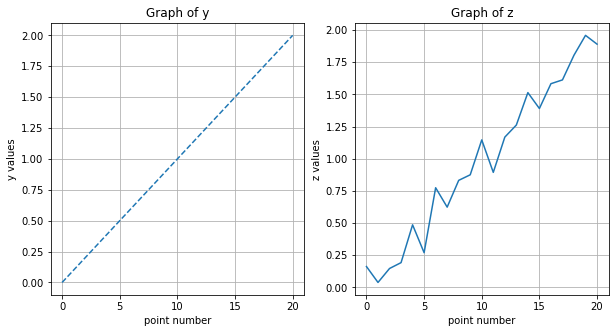

In [3]:
# Put your code here
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(y,'--')
plt.xlabel('point number')
plt.ylabel('y values')
plt.title('Graph of y')
plt.grid()
plt.subplot(1,2,2)
plt.plot(z)
plt.xlabel('point number')
plt.ylabel('z values')
plt.title('Graph of z')
plt.grid()


## 2. Fitting Linear (1st-Order Polynomial) Models to Data

### &#9989;&nbsp; Question 2: (3 points)

In this question, you should use *scipy.optimize.curve_fit* function for these two data sets. 

Please fit linear functions to both of pure data and noisy data, and **plot** your predicted functions with the original data sets in sub-plots. Remember to add legends.

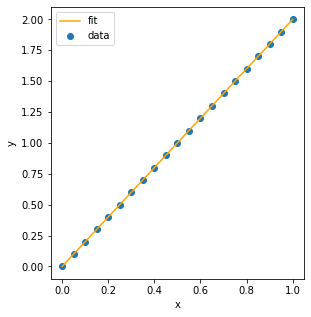

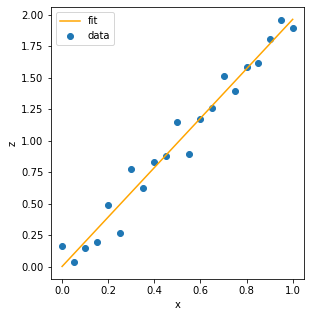

In [4]:
# Put your code here
#Pure data:
def func(x,A,B):
    return A*x+B


popt, pcov = curve_fit(func, x,y)

a_fit=popt[0]
b_fit=popt[1]
y_fit = func(x, a_fit,b_fit)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
# plot our actual data
plt.scatter(x, y, label = "data")

# plot our fitted curve
plt.plot(x, y_fit, color = "orange", label = "fit")

plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.show()

#Noise data:
popt, pcov = curve_fit(func, x,z)

a_fit1=popt[0]
b_fit1=popt[1]
z_fit1 = func(x, a_fit1,b_fit1)
plt.figure(figsize=(10,5))

plt.subplot(1,2,2)
# plot our actual data
plt.scatter(x, z, label = "data")

# plot our fitted curve
plt.plot(x, z_fit1, color = "orange", label = "fit")

plt.legend()
plt.xlabel('x')
plt.ylabel('z')
plt.show()

## 3. Exploring Linear Model Fits

### &#9989;&nbsp; Question 3.1: (4 points)

Please **print out** all the fitted model parameters for the pure data set in Question 2, and **answer** the following questions.
- For pure data, what are the expected fitted parameters? Please explain the reason.
- Do you get the exact parameters?

In [5]:
# Put your code here
print('a_fit:',a_fit,'b_fit:',b_fit)

a_fit: 2.0000000004751963 b_fit: 7.08738688593091e-22


<font size=+3>&#9998;</font> *Put your answers here.*
- For pure data, the expected fitted parameters are 2 and 0 because the equation is y = 2x + 0, which corresponds to y = Ax + B in a way that A = 2 and B = 0
- The parameters I get arent exact but very close.

### &#9989;&nbsp; Question 3.2: (5 points)

Please **print out** all the fitted model parameters for the noisy data set in Question 2, and **answer** the following questions.
- For noisy data, what are the expected fitted parameters? Please explain the reason.
- Do you get the exact parameters?
- Are this result close to the answer in Questions 3.1?

In [6]:
# Put your code here
print('a_fit:',a_fit1,'b_fit:',b_fit1)

a_fit: 1.9605329433528382 b_fit: 0.0017910920359444082


<font size=+3>&#9998;</font> *Put your answers here.*
- For the noisy data, the expected fitted parameters are now a bit around 2 and 0 instead of being exact because this data also has some noisy data points added which should make a very slight difference.
- The parameters I get are expected.
- They are fairly close.

### &#9989;&nbsp; Question 3.3: (5 points)

Now, fit linear functions to the noisy data again just like Questions 1 and 2, but this time, we will use different noise options in `np.random.normal` for our noisy data, i.e., Gaussian noise with mean zero and standard deviation 0.01. Please **plot** your predicted functions with the new noisy data, **print out** the fitted model parameters, and **answer** the following questions.
- Comparing to the results you got in Question 2, what kind of change to the noisy data can you observe?
- Comparing to the results you got in Question 2, what kind of change to the fitted function can you observe?
- Comparing to the results you got in Question 3.2, what kind of change to the fitted model parameters can you observe?

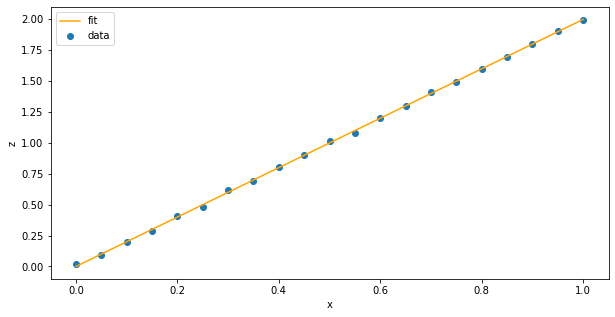

a_fit: 1.9960532974722964 b_fit: 0.00017910891134897966


In [7]:
# Put your code here
np.random.seed(seed = 1)
noise2 = np.random.normal(0, 0.01, x.size)
z2 = y + noise2

popt, pcov = curve_fit(func, x,z2)

a_fit2=popt[0]
b_fit2=popt[1]
z_fit2 = func(x, a_fit2,b_fit2)
plt.figure(figsize=(10,5))

# plot our actual data
plt.scatter(x, z2, label = "data")

# plot our fitted curve
plt.plot(x, z_fit2, color = "orange", label = "fit")

plt.legend()
plt.xlabel('x')
plt.ylabel('z')
plt.show()
print('a_fit:',a_fit2,'b_fit:',b_fit2)

<font size=+3>&#9998;</font> *Put your answers here.*
- Noisy data now is less noisy than before in the sense that it is less haphazard.
- The fitted function fits in a better way than before since the points are now closer to it now.
- The parameters A and B are now closer to 2 and 0 respectively.

### &#9989;&nbsp; Question 3.4: (5 points)

Fit linear functions to the noisy data again and take Gaussian noise with mean 2 and standard deviation 0.1. Please **plot** your predicted functions with the new noisy data, **print out** the fitted model parameters, and **answer** the following questions.
- Comparing to the results you got in Question 2, what kind of change to the noisy data can you observe?
- Comparing to the results you got in Question 2, what kind of change to the fitted function can you observe?
- Comparing to the results you got in Question 3.2, what kind of change to the fitted model parameters can you observe?

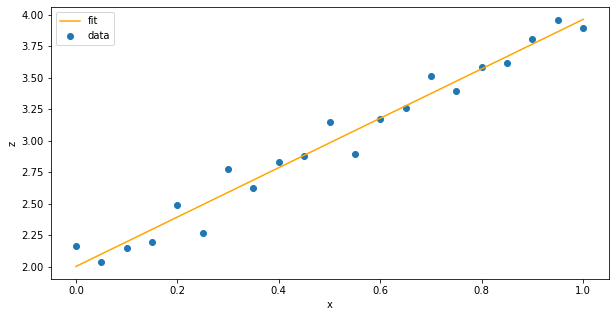

a_fit: 1.9605329433528373 b_fit: 2.0017910920403077


In [8]:
# Put your code here
np.random.seed(seed = 1)
noise3 = np.random.normal(2, 0.1, x.size)
z3 = y + noise3

popt, pcov = curve_fit(func, x,z3)

a_fit3=popt[0]
b_fit3=popt[1]
z_fit3 = func(x, a_fit3,b_fit3)
plt.figure(figsize=(10,5))

# plot our actual data
plt.scatter(x, z3, label = "data")

# plot our fitted curve
plt.plot(x, z_fit3, color = "orange", label = "fit")

plt.legend()
plt.xlabel('x')
plt.ylabel('z')
plt.show()
print('a_fit:',a_fit3,'b_fit:',b_fit3)

<font size=+3>&#9998;</font> *Put your answers here.*
- The noisy data is again more noisy now in the sense that it's more haphazard
- The fitted function is now a bit farther than the data points
- The A parameter is close to 2 but now so is the B parameter.

## 4. Fitting Quartic (4th-Order Polynomial) Functions


### &#9989;&nbsp; Question 4.1: (1 points)

To improve the fitting, one idea is to add more parameters in the model, so that the model can be more flexible. For example, we can take polynomials with higher orders, say quardratic (2nd order) polynomials, cubic (3rd order) polynomials, quartic (4th order) polynomials, ... rather than linear (1st order) polynomials.

Let's try quartic (4th order) polynomials in this question. Here are some examples of quartic polynomials
$$
y(x) = 2x^4 - 3, \\
y(x) = 0.5x^4 + 1.75x^3 + 3x^2 - x + 7.
$$

Please **answer** the following question.
- How many (fit) parameters are there in a general quartic (4th order) polynomial?

<font size=+3>&#9998;</font> *Put your answer here.*
- 5

### &#9989;&nbsp; Question 4.2: (4 points)

Please fit quartic polynomials to pure data and the original noisy data (takeing Gaussian noise with mean zero and standard deviation 0.1). Please **plot** your new fitting functions based on the plots in Question 2. That is to say, plot two subplots for pure data and noisy data, and plot the linear fittings and the quartic fittings on them.

<Figure size 720x360 with 0 Axes>

<Figure size 720x360 with 0 Axes>

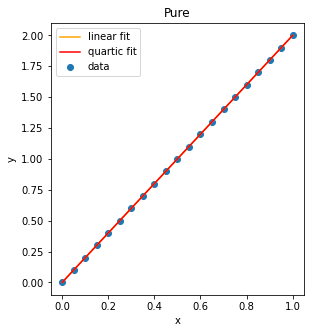

Linear in Pure: a_fit: 2.0000000004751963 b_fit: 7.08738688593091e-22
Quartic in Pure: a_fit: 4.412657791171811e-07 b_fit: -8.826852431065188e-07 c_fit: 5.645011920948117e-07 d_fit: 1.9999998752290347 e_fit: 5.520098249663786e-09


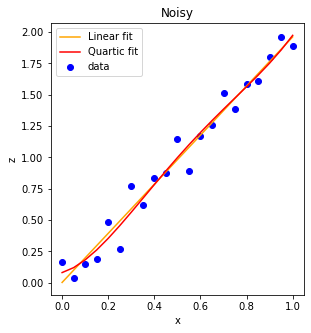

Linear in Noisy: a_fit: 1.9605329433528382 b_fit: 0.0017910920359444082
Quartic in Noisy: a_fit: 3.443902391986949 b_fit: -7.664932018987657 c_fit: 5.588026248281877 d_fit: 0.5270919456746522 e_fit: 0.08060228528375303


In [9]:
# Put your code here
def quartic(x,A,B,C,D,E):
    return A*x**4+B*x**3+C*x**2+D*x+E
np.random.seed(seed = 1)
noise = np.random.normal(0, 0.1, x.size)
z = y + noise

#Linear x Pure

popt, pcov = curve_fit(func, x,y)

a_fit_lp=popt[0]
b_fit_lp=popt[1]
y_fit_lp = func(x, a_fit_lp,b_fit_lp)
plt.figure(figsize=(10,5))

#Linear x Noisy

popt, pcov = curve_fit(func, x,z)

a_fit_ln=popt[0]
b_fit_ln=popt[1]
z_fit_ln = func(x, a_fit_ln,b_fit_ln)
plt.figure(figsize=(10,5))


#Quartic x Pure

popt, pcov = curve_fit(quartic, x,y)

a_fit_qp=popt[0]
b_fit_qp=popt[1]
c_fit_qp=popt[2]
d_fit_qp=popt[3]
e_fit_qp=popt[4]
y_fit_qp = quartic(x, a_fit_qp,b_fit_qp,c_fit_qp,d_fit_qp,e_fit_qp)
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.scatter(x, y, label = "data")

plt.plot(x, y_fit_lp, color = "orange", label = "linear fit")

plt.legend()

plt.plot(x, y_fit_qp, color = "red", label = "quartic fit")

plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Pure')

plt.show()
print('Linear in Pure:','a_fit:',a_fit_lp,'b_fit:',b_fit_lp)

print('Quartic in Pure:','a_fit:',a_fit_qp,'b_fit:',b_fit_qp,'c_fit:',c_fit_qp,'d_fit:',d_fit_qp,'e_fit:',e_fit_qp)

#Quartic x Noisy

popt, pcov = curve_fit(quartic, x,z)

a_fit_qn=popt[0]
b_fit_qn=popt[1]
c_fit_qn=popt[2]
d_fit_qn=popt[3]
e_fit_qn=popt[4]

z_fit_qn = quartic(x, a_fit_qn,b_fit_qn,c_fit_qn,d_fit_qn,e_fit_qn)
plt.figure(figsize=(10,5))

plt.subplot(1,2,2)
plt.scatter(x, z, color='blue',label = "data")

plt.plot(x, z_fit_ln, color = "orange", label = "Linear fit")

plt.plot(x, z_fit_qn, color = "red", label = "Quartic fit")

plt.legend()
plt.xlabel('x')
plt.ylabel('z')
plt.title('Noisy')

plt.show()

print('Linear in Noisy:','a_fit:',a_fit_ln,'b_fit:',b_fit_ln)
print('Quartic in Noisy:', 'a_fit:',a_fit_qn,'b_fit:',b_fit_qn,'c_fit:',c_fit_qn,'d_fit:',d_fit_qn,'e_fit:',e_fit_qn)


## 5. Exploring Quartic Model Fits

### &#9989;&nbsp; Question 5.1: (5 points)

Please **print out** new fitted model parameters for the both data sets in Question 4, and **answer** the following questions:
- For pure data, what are the expected fitted parameters for the quartic polynomial? Please explain the reason. 
- Do you get the exact parameters?
- For quartic fitting to the noisy data, is that optimized parameter close to the one from the pure data?

In [10]:
# Put your code here
print('Quartic in Noisy:', 'a_fit:',a_fit_qn,'b_fit:',b_fit_qn,'c_fit:',c_fit_qn,'d_fit:',d_fit_qn,'e_fit:',e_fit_qn)
print('Quartic in Pure:','a_fit:',a_fit_qp,'b_fit:',b_fit_qp,'c_fit:',c_fit_qp,'d_fit:',d_fit_qp,'e_fit:',e_fit_qp)
print('Linear in Noisy:','a_fit:',a_fit_ln,'b_fit:',b_fit_ln)
print('Linear in Pure:','a_fit:',a_fit_lp,'b_fit:',b_fit_lp)


Quartic in Noisy: a_fit: 3.443902391986949 b_fit: -7.664932018987657 c_fit: 5.588026248281877 d_fit: 0.5270919456746522 e_fit: 0.08060228528375303
Quartic in Pure: a_fit: 4.412657791171811e-07 b_fit: -8.826852431065188e-07 c_fit: 5.645011920948117e-07 d_fit: 1.9999998752290347 e_fit: 5.520098249663786e-09
Linear in Noisy: a_fit: 1.9605329433528382 b_fit: 0.0017910920359444082
Linear in Pure: a_fit: 2.0000000004751963 b_fit: 7.08738688593091e-22


<font size=+3>&#9998;</font> *Put your answers here.*
- For pure data in quartic function, the expected parameters are A,B,C,E=0 while D =2. This is because the equation for the data in pure data is y=2x+0 and when compared to y=Ax^4+Bx^3+Cx^2+Dx+E, A,B,C,E are clearly supposed to be 0 while D is supposed to be 2
- No, however, the parameters I got were very close.
- No.

### &#9989;&nbsp; Question 5.2: (4 points)

Let's focus on the noisy data and its linear and quartic fittings you have found in Question 4. Please **plot** both fitted functions on a larger domain $-1 \leq x \leq 2$, and **answer** the following question:
- On the larger domain $-1 \leq x \leq 2$, do you think the quartic fitting is close to a linear function or not?
- Based on your fitted parameters and the expression of the quartic polynomial, which terms in the polynomial play a key role in the prediction at $x = 2$?
- In predicting values outside the range of data, which model is more sensitive to the noise, linear one or quartic one?

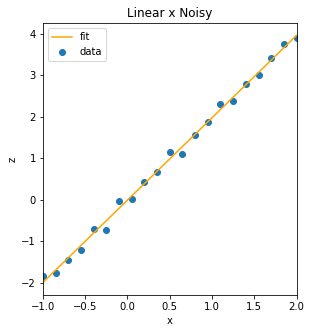

Linear in Noisy: a_fit: 1.9868443125269581 b_fit: -0.011364596715240038


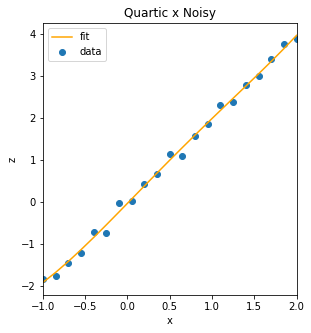

Quartic in Noisy: a_fit: 0.04251731187344586 b_fit: -0.11381709776146633 c_fit: 0.024336543937057194 d_fit: 2.06922438950653 e_fit: -0.03084430252019487


In [11]:
# Put your code here
x_new = np.linspace(-1,2,21)
y_new= 2*x_new
np.random.seed(seed=1)
noise_new=np.random.normal(0,0.1,x.size)
z_new=y_new+noise_new
popt, pcov = curve_fit(func, x_new,z_new)

a_fit_ln=popt[0]
b_fit_ln=popt[1]
z_fit_ln_new = func(x_new, a_fit_ln,b_fit_ln)
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
# plot our actual data
plt.scatter(x_new, z_new, label = "data")

# plot our fitted curve
plt.plot(x_new, z_fit_ln_new, color = "orange", label = "fit")

plt.legend()
plt.xlabel('x')
plt.ylabel('z')
plt.title('Linear x Noisy')
plt.xlim(-1,2)
plt.show()
print('Linear in Noisy:','a_fit:',a_fit_ln,'b_fit:',b_fit_ln)


popt, pcov = curve_fit(quartic, x_new,z_new)

a_fit_qn=popt[0]
b_fit_qn=popt[1]
c_fit_qn=popt[2]
d_fit_qn=popt[3]
e_fit_qn=popt[4]

z_fit_qn_new = quartic(x_new, a_fit_qn,b_fit_qn,c_fit_qn,d_fit_qn,e_fit_qn)
plt.figure(figsize=(10,5))

plt.subplot(1,2,2)
# plot our actual data
plt.scatter(x_new, z_new, label = "data")

# plot our fitted curve
plt.plot(x_new, z_fit_qn_new, color = "orange", label = "fit")

plt.legend()
plt.xlabel('x')
plt.ylabel('z')
plt.title('Quartic x Noisy')
plt.xlim(-1,2)

plt.show()
print('Quartic in Noisy:', 'a_fit:',a_fit_qn,'b_fit:',b_fit_qn,'c_fit:',c_fit_qn,'d_fit:',d_fit_qn,'e_fit:',e_fit_qn)


<font size=+3>&#9998;</font> *Put your answers here.*
- It looks close to a linear function
- D (the coefficient of x)
- quartic

## 6. (Quantitatively) Evaluating the Model Fits


### &#9989;&nbsp; Question 6: (6 points)

A simple approach that evaluates the quality of the fitting is to measure the mean squared error (MSE). That is, given the data $\{ (a_i, b_i) \} _{i = 1} ^N$, and the fitted model $f$, we shall calculate the  mean squared error
$$ MSE := \frac{1}{N}\sum_{i=1}^{N} (f(a_i) - b_i) ^2.$$

First, please **write** function *MSE*, which has two inputs and one output:
- Input 1: the $y$ data $f(a)$ as a *numpy.ndarray*,
- Input 2: the model fit $y$-value $b$ as a *numpy.ndarray* (with the same size as Input 1),
- Output: the mean squared error $MSE$ as a *float*.

Then, **calculate** the MSE with respect to the data and fitted models we have done in Question 4:
1. pure data, with linear fit,
1. pure data, with quartic fit,
1. noisy data, with linear fit,
1. noisy data, with quartic fit.

Finally, **answer** the following question:
- When considering the noisy data, which fit model has less MSE? Please explain the reason.

In [12]:
# Put your code here
def MSE(a,b):
    MSE=0
    for i in range(len(a)):
        MSE+=((a[i]-b[i])**2)/(len(a))
    return MSE
print('Pure Data with Linear Fit: ', MSE(y,y_fit_lp))
print('Pure Data with Quartic Fit: ', MSE(y,y_fit_qp))
print('Noisy Data with Linear Fit: ', MSE(z,z_fit_ln))
print('Noisy Data with Quartic Fit: ', MSE(z,z_fit_qn))

Pure Data with Linear Fit:  7.715227542137875e-20
Pure Data with Quartic Fit:  7.18258655440839e-18
Noisy Data with Linear Fit:  0.011801249264574072
Noisy Data with Quartic Fit:  0.011124679046112602


<font size=+3>&#9998;</font> *Put your answer here.*
- Quartic fit model has lesser MSE by about 0.0007. It is because higher order functions mostly end up having a better fit than lower order functions when noisy data is considered since they have more parameters.

## 7. Reflecting on Model Fitting

### &#9989;&nbsp; Question 7: (2 points)

The previous questions are based on artificial data, but for real-world data, the we will have the same question about how to choose the fitted model. Please **answer** the following questions:
- Is it true the models with more parameters (or with larger function space) is better?
- For real-world data, what kind of fitting models shall we choose?

<font size=+3>&#9998;</font> *Put your answers here.*
- Not always. Like in the previous question, the linear fit with pure data had a lower MSE than the quartic fit with pure data. 
- Real world data however, is expected to have noisy data points since things are rarely ideal. Hence, higher order fitting models should be chosen.

---

### Congratulations, you're done!

Submit this assignment by uploading it to the course Desire2Learn web page.  
Go to the "Homework Assignments" section, find the appropriate submission folder link, and upload it there.


&#169; Copyright 2022, [Department of Computational Mathematics, Science and Engineering](https://cmse.msu.edu) at Michigan State University.